In [11]:
import numpy as np
import matplotlib.pyplot as plt
from repeaters_NV import RepeaterParams
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

sns.set_theme(style="white", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.bottom": True,
    "ytick.left": True,
    "figure.autolayout": True
})

def entanglement_rate_vs_distance(params, distances):
    """
    Elementary entanglement generation rate [pairs/s]
    as a function of elementary link distance.
    """

    distances = np.asarray(distances)

    # Each photon travels half the elementary link
    half_dist = distances / 2

    P_click = (
        params.p_det
        * params.eta_c
        * params.eta_M
        * 10 ** (-params.alpha * half_dist / 10)
    )

    # Probability both photons arrive and a Bell-state measurement succeeds
    P_both = 0.5 * P_click**2

    # Expected rate
    rate = params.nu * P_both

    return rate

In [3]:
params = RepeaterParams()
params.p_det = 0.95
params.alpha = 0.18
params.V = 0.95
params.nu = 10e6
params.R_dark = 100
params.delta_det = 100e-12
params.eta_c = 0.8
params.P_BSM = 0.9993
params.eta_M = 0.46
params.T_coh = 10


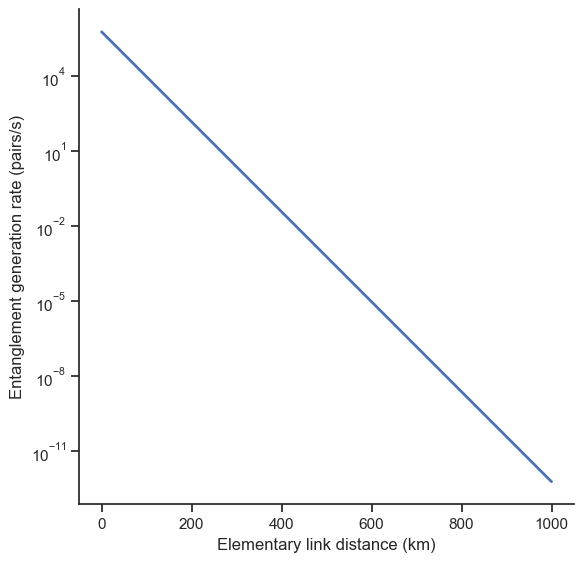

In [20]:
distances = np.linspace(0, 1000, 500)

rates = entanglement_rate_vs_distance(params, distances)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(distances, rates, lw=2)
ax.set_yscale('log')
ax.set_xlabel("Elementary link distance (km)")
ax.set_ylabel("Entanglement generation rate (pairs/s)")
ax.set_box_aspect(1) # Forces the plot area to be perfectly square
# Enable minor tick labels and set formatter
plt.tick_params(axis='y', which='minor')

plt.savefig('tests/prunning.png', bbox_inches='tight')
plt.show()